In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# define state
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    runs_in_boundary_percentage: float
    summary: str

In [3]:
def calc_strike_rate(state: BatsmanState):

    sr = (state["runs"] / state["balls"]) * 100

    # state['strike_rate'] = sr

    return {"strike_rate": sr}

In [4]:
def calc_balls_per_boundary(state: BatsmanState):

    fours = state["fours"]
    sixes = state["sixes"]
    balls = state["balls"]

    bpb = balls / (sixes + fours)

    # state["balls_per_boundary"] = bpb

    return {"balls_per_boundary": bpb}

In [5]:
def calc_boundary_percentage(state: BatsmanState):

    fours = state["fours"]
    sixes = state["sixes"]
    runs = state["runs"]

    r_in_bp = (((fours * 4) + (sixes * 6)) / runs) * 100

    # state["runs_in_boundary_percentage"] = r_in_bp

    return {"runs_in_boundary_percentage": r_in_bp}

In [6]:
def batsman_summary(state: BatsmanState):

    summary = f"""
    Strike_rate -> {state['strike_rate']} \n
    Balls per Boundary -> {state['balls_per_boundary']} \n
    Runs in Boundary Percentage -> {state['runs_in_boundary_percentage']}
    """

    # state["summary"] = summary

    return {"summary": summary}

In [7]:
# define a graph
graph = StateGraph(BatsmanState)

# add nodes
graph.add_node("calc_strike_rate", calc_strike_rate)
graph.add_node("calc_balls_per_boundary", calc_balls_per_boundary)
graph.add_node("calc_boundary_percentage", calc_boundary_percentage)
graph.add_node("batsman_summary", batsman_summary)

# add edges
graph.add_edge(START, "calc_strike_rate")
graph.add_edge(START, "calc_balls_per_boundary")
graph.add_edge(START, "calc_boundary_percentage")

graph.add_edge("calc_strike_rate", "batsman_summary")
graph.add_edge("calc_balls_per_boundary", "batsman_summary")
graph.add_edge("calc_boundary_percentage", "batsman_summary")

graph.add_edge("batsman_summary", END)

# compile the graph
workflow = graph.compile()

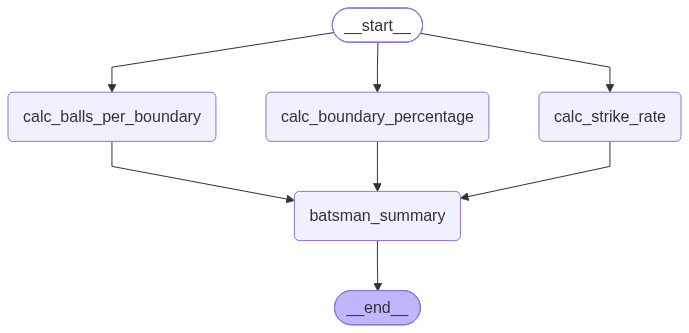

In [8]:
workflow

In [9]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(initial_state)
print(final_state['summary'])


    Strike_rate -> 200.0 

    Balls per Boundary -> 5.0 

    Runs in Boundary Percentage -> 48.0
    
